In [5]:
import os
import torch
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Configurations
args = {
    "model_name": "gpt2",
    "wiki_dataset_name": "wikitext",
    "wiki_dataset_config": "wikitext-2-raw-v1",
    "wiki_split": "train",
    "financial_dataset_name": "financial_phrasebank",
    "financial_dataset_config": "sentences_50agree",
    "financial_split": "train",
    "max_texts": 30000,
    "batch_size": 64,
    "drift_threshold_std": 4.0,
    "window_size": 50,
    "output_dir": "results_revised",
}

# Ensure output directory exists
os.makedirs(args["output_dir"], exist_ok=True)

# Load Model and Tokenizer
print("Loading GPT-2 model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(args["model_name"])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Set pad_token to eos_token
model = AutoModelForCausalLM.from_pretrained(args["model_name"]).to(device)
model.eval()

# Utility: Batch Generator
def batch_generator(data, batch_size):
    """Yield consecutive batches from the input data."""
    for i in range(0, len(data), batch_size):
        yield data[i:i + batch_size]

# Utility: Extract Embeddings
def extract_embeddings(model, tokenizer, texts, device):
    """
    Tokenize and extract mean-pooled embeddings from GPT-2 outputs.
    """
    encodings = tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=512
    ).to(device)
    with torch.no_grad():
        outputs = model(input_ids=encodings.input_ids, attention_mask=encodings.attention_mask)
        hidden_states = outputs[0]  # First element is the hidden states
        mask = encodings.attention_mask.unsqueeze(-1)  # [batch_size, seq_length, 1]
        mask_sum = mask.sum(dim=1, keepdims=True)  # [batch_size, 1, 1]
        mask_sum[mask_sum == 0] = 1  # Prevent division by zero
        embeddings = (hidden_states * mask).sum(dim=1) / mask_sum.squeeze(-1)
    return embeddings.cpu().numpy()


# Drift Detection Class
class DriftDetector:
    def __init__(self, model, tokenizer, device, args):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.args = args
        self.prototype = None
        self.drift_indices = []
        self.similarity_scores = []

    def initialize_baseline(self, texts):
        """Initialize prototype embedding from baseline data."""
        print("Initializing baseline prototype...")
        batches = batch_generator(texts, self.args["batch_size"])
        embeddings = [extract_embeddings(self.model, self.tokenizer, batch, self.device) for batch in tqdm(batches)]
        embeddings = np.concatenate(embeddings, axis=0)
        self.prototype = np.mean(embeddings, axis=0)
        print("Baseline prototype initialized.")

    def detect_drifts(self, texts):
        """Detect drifts by comparing batch embeddings to the prototype."""
        print("Detecting drifts...")
        batches = batch_generator(texts, self.args["batch_size"])
        for i, batch in enumerate(tqdm(batches)):
            embeddings = extract_embeddings(self.model, self.tokenizer, batch, self.device)
            mean_embedding = np.mean(embeddings, axis=0, keepdims=True)
            similarity = cosine_similarity(mean_embedding, [self.prototype])[0][0]
            self.similarity_scores.append(similarity)

            # Check for drift
            if len(self.similarity_scores) >= self.args["window_size"]:
                threshold = self._calculate_threshold()
                if similarity < threshold:
                    drift_index = i * self.args["batch_size"]
                    self.drift_indices.append(drift_index)
                    print(f"Drift detected at index={drift_index}, similarity={similarity:.4f}")

    def _calculate_threshold(self):
        """Calculate the drift threshold using rolling mean and std."""
        recent_scores = self.similarity_scores[-self.args["window_size"]:]
        mean_score = np.mean(recent_scores)
        std_dev = np.std(recent_scores)
        return mean_score - (self.args["drift_threshold_std"] * std_dev)

# Load Datasets
print("Loading datasets...")
wiki_dataset = load_dataset(args["wiki_dataset_name"], args["wiki_dataset_config"], split=args["wiki_split"])
texts = wiki_dataset["text"][: args["max_texts"]]
financial_dataset = load_dataset(args["financial_dataset_name"], args["financial_dataset_config"], split=args["financial_split"])
financial_texts = financial_dataset["sentence"]

# Simulate Domain Drifts
print("Simulating domain drifts...")
drift_start_1, drift_end_1 = len(texts) // 3, len(texts) // 2
drift_start_2, drift_end_2 = 2 * len(texts) // 3, 5 * len(texts) // 6
texts[drift_start_1:drift_end_1] = financial_texts[: drift_end_1 - drift_start_1]
texts[drift_start_2:drift_end_2] = financial_texts[: drift_end_2 - drift_start_2]
print(f"Drift regions: [{drift_start_1}, {drift_end_1}), [{drift_start_2}, {drift_end_2})")

Using device: mps
Loading GPT-2 model and tokenizer...
Loading datasets...
Simulating domain drifts...
Drift regions: [10000, 15000), [20000, 25000)
Initializing baseline prototype...


157it [11:09,  4.27s/it]


Baseline prototype initialized.
Detecting drifts...


146it [11:10,  4.59s/it]


KeyboardInterrupt: 

Initializing baseline prototype...


157it [13:11,  5.04s/it]


Baseline prototype initialized.
Detecting drifts...


150it [12:42,  4.23s/it]

Drift detected at index=9536, similarity=0.9999


300it [20:05,  7.97s/it]

Drift detected at index=19136, similarity=0.9999


449it [28:00,  2.80s/it]

Drift detected at index=28672, similarity=0.9999


464it [29:49,  3.86s/it]


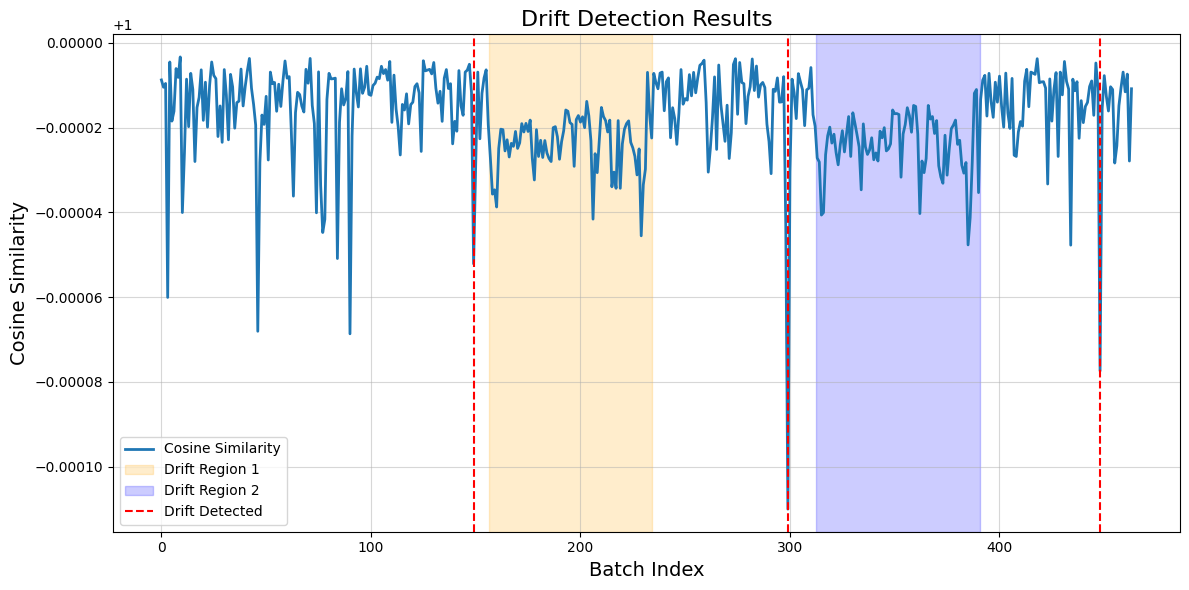

In [6]:
# Initialize Drift Detector
detector = DriftDetector(model, tokenizer, device, args)

# Run Drift Detection
detector.initialize_baseline(texts[:drift_start_1])  # Use first part as baseline
detector.detect_drifts(texts)

# Plot Results
plt.figure(figsize=(12, 6))
plt.plot(detector.similarity_scores, label="Cosine Similarity", linewidth=2)
plt.axvspan(drift_start_1 / args["batch_size"], drift_end_1 / args["batch_size"], color="orange", alpha=0.2, label="Drift Region 1")
plt.axvspan(drift_start_2 / args["batch_size"], drift_end_2 / args["batch_size"], color="blue", alpha=0.2, label="Drift Region 2")
for idx in detector.drift_indices:
    plt.axvline(idx / args["batch_size"], color="red", linestyle="--", label="Drift Detected" if idx == detector.drift_indices[0] else "")
plt.title("Drift Detection Results", fontsize=16)
plt.xlabel("Batch Index", fontsize=14)
plt.ylabel("Cosine Similarity", fontsize=14)
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(args["output_dir"], "drift_detection_plot.png"))
plt.show()
